Rating summary:
count    970.000000
mean       2.258763
std        1.650553
min        0.000000
25%        1.000000
50%        2.300000
75%        3.700000
max        5.000000
Name: rating, dtype: float64


C:\Users\dhyan\AppData\Local\Temp\ipykernel_24544\3934140454.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].mean(), inplace=True)
C:\Users\dhyan\AppData\Local\Temp\ipykernel_24544\3934140454.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


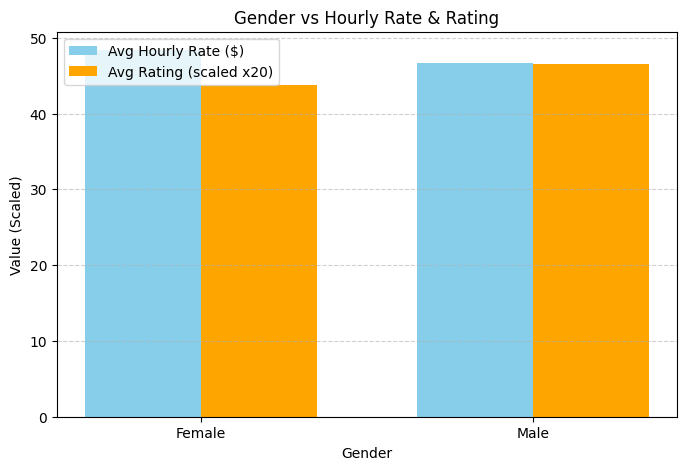

C:\Users\dhyan\AppData\Local\Temp\ipykernel_24544\3934140454.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby(age_bins)[["hourly_rate_usd", "rating"]].mean()


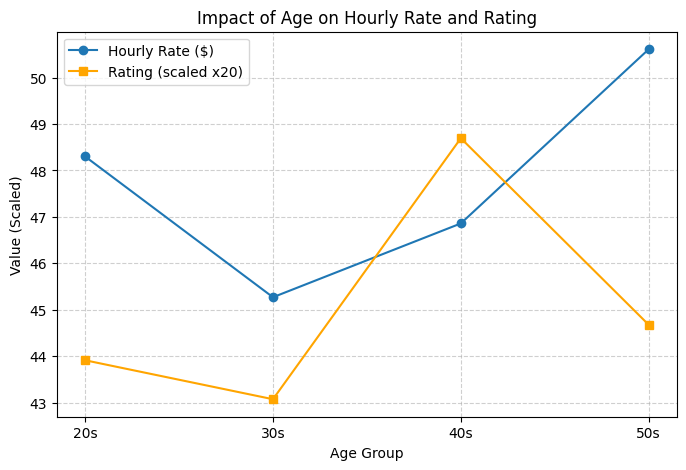

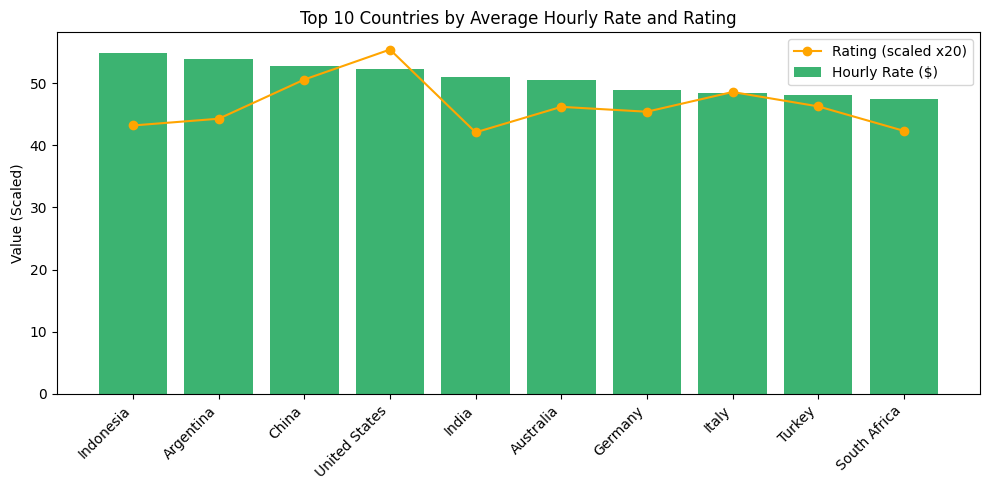

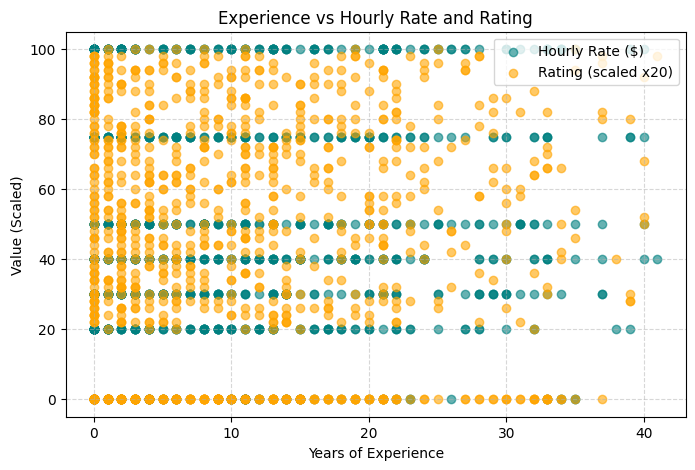

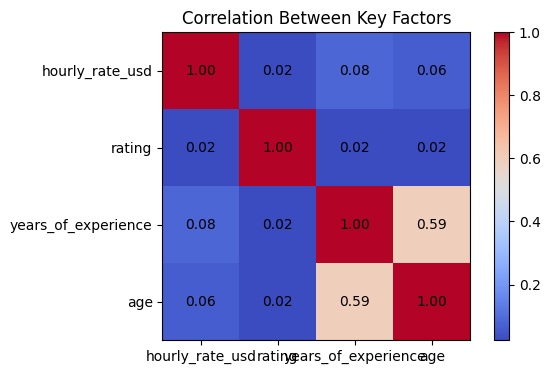

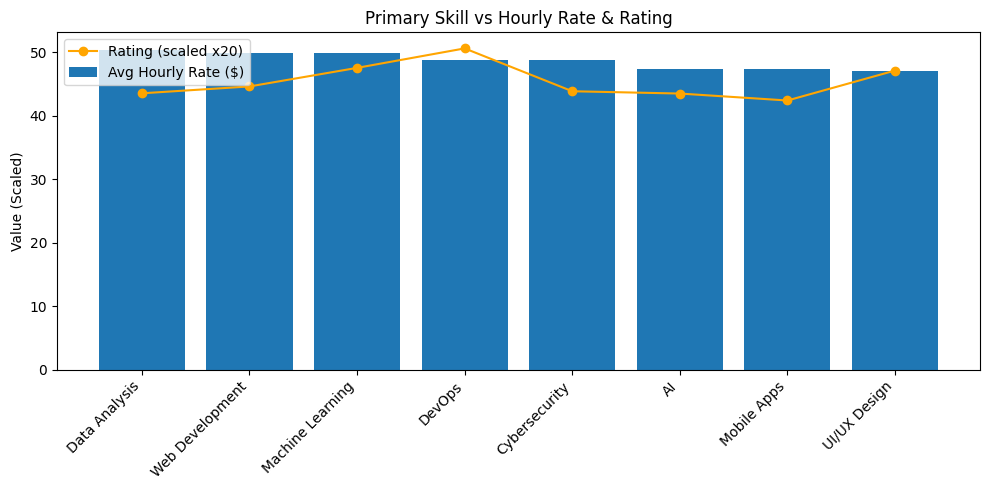

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("global_freelancers_clean.csv")

# -----------------------------
# Fix & Clean Numeric Columns
# -----------------------------
df["hourly_rate_usd"] = df["hourly_rate_usd"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
df["hourly_rate_usd"] = pd.to_numeric(df["hourly_rate_usd"], errors="coerce")

# Fix rating — extract numeric if stored as text
def extract_rating(x):
    if pd.isna(x): return np.nan
    x = str(x)
    nums = re.findall(r"\d+\.?\d*", x)
    if nums:
        val = float(nums[0])
        if val > 10: val = val / 20
        return val
    return np.nan

df["rating"] = df["rating"].apply(extract_rating)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce").clip(0, 5)

df["rating"].fillna(df["rating"].mean(), inplace=True)
df["hourly_rate_usd"].fillna(df["hourly_rate_usd"].median(), inplace=True)
df.dropna(subset=["gender", "age", "country", "primary_skill"], inplace=True)

# -----------------------------
# Rating Check
# -----------------------------
print("Rating summary:")
print(df["rating"].describe())

# -----------------------------
# 1️⃣ Gender vs Hourly Rate & Rating
# -----------------------------
gender_stats = df.groupby("gender")[["hourly_rate_usd", "rating"]].mean()

plt.figure(figsize=(8,5))
x = np.arange(len(gender_stats))
width = 0.35
plt.bar(x - width/2, gender_stats["hourly_rate_usd"], width, label='Avg Hourly Rate ($)', color='skyblue')
plt.bar(x + width/2, gender_stats["rating"]*20, width, label='Avg Rating (scaled x20)', color='orange')
plt.xticks(x, gender_stats.index)
plt.title("Gender vs Hourly Rate & Rating")
plt.xlabel("Gender")
plt.ylabel("Value (Scaled)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# -----------------------------
# 2️⃣ Age vs Hourly Rate & Rating
# -----------------------------
age_bins = pd.cut(df["age"], bins=[20,30,40,50,60,70,80], labels=["20s","30s","40s","50s","60s","70s"])
age_stats = df.groupby(age_bins)[["hourly_rate_usd", "rating"]].mean()

plt.figure(figsize=(8,5))
plt.plot(age_stats.index, age_stats["hourly_rate_usd"], marker='o', label="Hourly Rate ($)")
plt.plot(age_stats.index, age_stats["rating"]*20, marker='s', label="Rating (scaled x20)", color='orange')
plt.title("Impact of Age on Hourly Rate and Rating")
plt.xlabel("Age Group")
plt.ylabel("Value (Scaled)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# -----------------------------
# 3️⃣ Country vs Hourly Rate
# -----------------------------
country_stats = df.groupby("country")[["hourly_rate_usd", "rating"]].mean().sort_values(by="hourly_rate_usd", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(country_stats.index, country_stats["hourly_rate_usd"], color='mediumseagreen', label="Hourly Rate ($)")
plt.plot(country_stats.index, country_stats["rating"]*20, color='orange', marker='o', label="Rating (scaled x20)")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Average Hourly Rate and Rating")
plt.ylabel("Value (Scaled)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4️⃣ Experience vs Hourly Rate & Rating
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(df["years_of_experience"], df["hourly_rate_usd"], alpha=0.6, label="Hourly Rate ($)", color='teal')
plt.scatter(df["years_of_experience"], df["rating"]*20, alpha=0.6, label="Rating (scaled x20)", color='orange')
plt.title("Experience vs Hourly Rate and Rating")
plt.xlabel("Years of Experience")
plt.ylabel("Value (Scaled)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# -----------------------------
# 5️⃣ Correlation Matrix (Without Seaborn)
# -----------------------------
corr = df[["hourly_rate_usd","rating","years_of_experience","age"]].corr()
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(corr, cmap="coolwarm")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)
plt.title("Correlation Between Key Factors")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.colorbar(im)
plt.show()

# -----------------------------
# 6️⃣ Skill vs Avg Hourly Rate & Rating
# -----------------------------
skill_stats = df.groupby("primary_skill")[["hourly_rate_usd","rating"]].mean().sort_values(by="hourly_rate_usd", ascending=False).head(8)

plt.figure(figsize=(10,5))
plt.bar(skill_stats.index, skill_stats["hourly_rate_usd"], label="Avg Hourly Rate ($)")
plt.plot(skill_stats.index, skill_stats["rating"]*20, marker='o', color='orange', label="Rating (scaled x20)")
plt.xticks(rotation=45, ha="right")
plt.title("Primary Skill vs Hourly Rate & Rating")
plt.ylabel("Value (Scaled)")
plt.legend()
plt.tight_layout()
plt.show()
